In [1]:
import pickle
import behavior.boris_extraction as boris
import spike.spike_analysis.spike_collection as sc
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import sem
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import matplotlib.patches as mpatches
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))

# Load collection and create behavior dataframe 

In [2]:
only_subject_collection = sc.SpikeCollection.load_collection(r'C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\only_subjects_spike_collection\spike_collection.json')
event_info = {}
is_first = True
sniff_itis = []
total_sniffs = 0
for recording in only_subject_collection.recordings:
    for event, events in recording.event_dict.items():
        no_events = events.shape[0]
        sniff_length = 0
        for i in range(len(events)):
            if (event == 'acquisition') and is_first: 
                first_five_min = events[i][0] + 300000
                is_first = False
            if (event == 'acquisition') | (event == 'exposure 0'):
               if events[i][0] < first_five_min:
                   sniff_length_temp = events[i][1] - events[i][0]
                   sniff_length = sniff_length +sniff_length_temp
                   total_sniffs = total_sniffs + 1
               else:
                   pass
            else:
                sniff_length_temp = events[i][1] - events[i][0]
                sniff_length = sniff_length +sniff_length_temp
                total_sniffs = total_sniffs + 1
            try:
                sniff_iti = events[i+1][0] - events[i][1]
                sniff_itis.append(sniff_iti)
            except IndexError:
                pass
        total_sniff_time = sniff_length/1000
        avg_event = sniff_length/no_events/1000
        if (recording.name + recording.subject) in event_info.keys():
            dict_event = event_info[recording.name + recording.subject]
            dict_event[event] =  {'no_events': no_events, 'avg event': avg_event, 'total time': total_sniff_time}
            event_info[recording.name + recording.subject] =  dict_event
        else:
            event_info[recording.name + recording.subject] = {event: {'no_events': no_events, 'avg event': avg_event,'total time': total_sniff_time }}
        
event_info_df = pd.DataFrame.from_dict(event_info)
sniff_itis = np.array(sniff_itis)/1000
sniff_itis 
overlapping_sniffs = 0 
for i in range(len(sniff_itis)):
    if sniff_itis[i] < 4:
        overlapping_sniffs = overlapping_sniffs + 1
print(overlapping_sniffs) # 212 with 5 and 106 with 2 out of 532
print(total_sniffs) #after fixing 0 for 2 out of 424, and 107 for less than 5



523
2192


In [3]:
event_overview = pd.concat({k: pd.DataFrame(v) for k, v in event_info.items()}, axis=0)
event_overview = event_overview.reset_index()
event_overview


,level_0,level_1,baseline,cagemate,exposure_1,exposure_2,exposure_3,familiar,novel
0,11_CNF_merged.rec1.1,no_events,12.0,47.000000,47.000000,38.000000,39.000000,39.000000,38.000000
1,11_CNF_merged.rec1.1,avg event,2.0,1.876856,1.876856,3.468418,2.943671,2.943671,3.468418
2,11_CNF_merged.rec1.1,total time,24.0,88.212250,88.212250,131.799900,114.803150,114.803150,131.799900
3,11_NCF_merged.rec1.1,no_events,12.0,13.000000,25.000000,13.000000,32.000000,32.000000,25.000000
4,11_NCF_merged.rec1.1,avg event,2.0,1.211127,1.719094,1.211127,1.474645,1.474645,1.719094
5,11_NCF_merged.rec1.1,total time,24.0,15.744650,42.977350,15.744650,47.188650,47.188650,42.977350
6,12_CNF_merged.rec1.2,no_events,12.0,39.000000,39.000000,23.000000,20.000000,20.000000,23.000000
7,12_CNF_merged.rec1.2,avg event,2.0,2.154615,2.154615,2.115872,1.593757,1.593757,2.115872
8,12_CNF_merged.rec1.2,total time,24.0,84.030000,84.030000,48.665050,31.875150,31.875150,48.665050
9,13_NCF_merged.rec1.3,no_events,12.0,18.000000,29.000000,18.000000,9.000000,9.000000,29.000000


In [4]:
events_df = event_overview[event_overview['level_1'] == 'no_events'][['level_0', 'level_1', 'cagemate', 'familiar', 'novel']].reset_index(drop=True)
exclude_recordings = ['22_FCN_merged.rec2.2', '11_NCF_merged.rec1.1', 
                      '21_NCF_merged.rec2.1', '23_CNF_merged.rec2.3',
                      '24_CNF_merged.rec2.4', '32_NFC_merged.rec3.2']  # fill in the ones you're dropping

# keep only selected recordings
events_df_filtered = events_df[~events_df['level_0'].isin(exclude_recordings)]
print(events_df_filtered[['cagemate', 'familiar', 'novel']].min())
print(events_df_filtered[['cagemate', 'familiar', 'novel']].describe())

cagemate     9.0
familiar     9.0
novel       10.0
dtype: float64
        cagemate   familiar      novel
count   9.000000   9.000000   9.000000
mean   21.333333  22.777778  26.555556
std    13.209845  10.697871  11.969870
min     9.000000   9.000000  10.000000
25%    13.000000  17.000000  18.000000
50%    18.000000  21.000000  23.000000
75%    21.000000  25.000000  38.000000
max    47.000000  40.000000  43.000000


In [5]:
events_df

,level_0,level_1,cagemate,familiar,novel
0,11_CNF_merged.rec1.1,no_events,47.0,39.0,38.0
1,11_NCF_merged.rec1.1,no_events,13.0,32.0,25.0
2,12_CNF_merged.rec1.2,no_events,39.0,20.0,23.0
3,13_NCF_merged.rec1.3,no_events,18.0,9.0,29.0
4,21_FCN_merged.rec2.1,no_events,15.0,12.0,14.0
5,21_NCF_merged.rec2.1,no_events,15.0,5.0,17.0
6,22_FCN_merged.rec2.2,no_events,3.0,14.0,11.0
7,22_NCF_merged.rec2.2,no_events,9.0,22.0,18.0
8,23_CNF_merged.rec2.3,no_events,9.0,43.0,27.0
9,23_NFC_merged.rec2.3,no_events,13.0,40.0,41.0


In [6]:


event_overview['order'] = event_overview['level_0'].apply(lambda x: x.split('_')[1])
event_overview['subject'] = event_overview['level_0'].astype(str).apply(lambda x: x.split('_')[0])
no_events = event_overview[event_overview['level_1'] == 'no_events']
FCN_df = event_overview[event_overview['order'] == 'FCN']
CNF_df = event_overview[event_overview['order'] == 'CNF']
NFC_df = event_overview[event_overview['order'] == 'NFC']
event_total_time = event_overview[event_overview['level_1'] == 'total time']
event_total_time_averages = {}
avg_events = []
sem_events = []
for event in ['familiar', 'novel', 'cagemate']:
    avg_event = event_total_time[event].mean()
    sem_event = sem(event_total_time[event])
    event_total_time_averages[event] = [avg_event, sem_event]
    avg_events.append(avg_event)
    sem_events.append(sem_event)
avg_events = np.array(avg_events)
sem_events = np.array(sem_events)
event_total_time_averages

{'familiar': [np.float64(53.00861000000023), np.float64(10.377457440039857)],
 'novel': [np.float64(69.96913666666701), np.float64(12.31413832933366)],
 'cagemate': [np.float64(39.018983333333296), np.float64(9.395176132428249)]}

In [7]:
event_overview

,level_0,level_1,baseline,cagemate,exposure_1,exposure_2,exposure_3,familiar,novel,order,subject
0,11_CNF_merged.rec1.1,no_events,12.0,47.000000,47.000000,38.000000,39.000000,39.000000,38.000000,CNF,11
1,11_CNF_merged.rec1.1,avg event,2.0,1.876856,1.876856,3.468418,2.943671,2.943671,3.468418,CNF,11
2,11_CNF_merged.rec1.1,total time,24.0,88.212250,88.212250,131.799900,114.803150,114.803150,131.799900,CNF,11
3,11_NCF_merged.rec1.1,no_events,12.0,13.000000,25.000000,13.000000,32.000000,32.000000,25.000000,NCF,11
4,11_NCF_merged.rec1.1,avg event,2.0,1.211127,1.719094,1.211127,1.474645,1.474645,1.719094,NCF,11
5,11_NCF_merged.rec1.1,total time,24.0,15.744650,42.977350,15.744650,47.188650,47.188650,42.977350,NCF,11
6,12_CNF_merged.rec1.2,no_events,12.0,39.000000,39.000000,23.000000,20.000000,20.000000,23.000000,CNF,12
7,12_CNF_merged.rec1.2,avg event,2.0,2.154615,2.154615,2.115872,1.593757,1.593757,2.115872,CNF,12
8,12_CNF_merged.rec1.2,total time,24.0,84.030000,84.030000,48.665050,31.875150,31.875150,48.665050,CNF,12
9,13_NCF_merged.rec1.3,no_events,12.0,18.000000,29.000000,18.000000,9.000000,9.000000,29.000000,NCF,13


In [8]:
subject_means = event_overview.groupby(['level_1', 'subject'])[['cagemate', 'familiar', 'novel']].mean()

# Step 2: Average across subjects for each level_1 category  
final_result = subject_means.groupby('level_1')[['cagemate', 'familiar', 'novel']].mean()
final_sem = subject_means.groupby('level_1')[['cagemate', 'familiar', 'novel']].sem()

final_result
final_sem

,cagemate,familiar,novel
level_1,,,
avg event,0.212022,0.293565,0.209730
no_events,3.734263,3.277406,3.183508
total time,12.076288,10.941751,11.579267


# Stats

In [9]:
event_total_time= event_total_time[['familiar', 'cagemate', 'novel']]
results = {}
p_values = pd.DataFrame(index=event_total_time.columns, columns=event_total_time.columns)
p_value_list = []
for pair in combinations(event_total_time.columns, 2):
    t_stat, p_value = ttest_rel(event_total_time[pair[0]],event_total_time[pair[1]])
    results[pair] = [t_stat, p_value]
    p_value_list.append(p_value)
            
results


{('familiar', 'cagemate'): [np.float64(1.1493745662985406),
  np.float64(0.2696590258196962)],
 ('familiar', 'novel'): [np.float64(-1.5726739076352223),
  np.float64(0.1381153947160291)],
 ('cagemate', 'novel'): [np.float64(-2.3891913778775615),
  np.float64(0.03151428610202051)]}

In [10]:
adjusted_p_values = multipletests(p_value_list, method='holm')
adjusted_p_values

(array([False, False, False]),
 array([0.27623079, 0.27623079, 0.09454286]),
 np.float64(0.016952427508441503),
 0.016666666666666666)

# Plotting

In [11]:
event_total_time_averages

{'familiar': [np.float64(53.00861000000023), np.float64(10.377457440039857)],
 'novel': [np.float64(69.96913666666701), np.float64(12.31413832933366)],
 'cagemate': [np.float64(39.018983333333296), np.float64(9.395176132428249)]}

In [12]:
subject_means = event_overview.groupby(['level_1', 'subject'])[['cagemate', 'familiar', 'novel']].mean()

# Step 2: Average across subjects for each level_1 category  
final_result = subject_means.groupby('level_1')[['cagemate', 'familiar', 'novel']].mean()
final_sem = subject_means.groupby('level_1')[['cagemate', 'familiar', 'novel']].sem()

final_result
final_sem

,cagemate,familiar,novel
level_1,,,
avg event,0.212022,0.293565,0.209730
no_events,3.734263,3.277406,3.183508
total time,12.076288,10.941751,11.579267


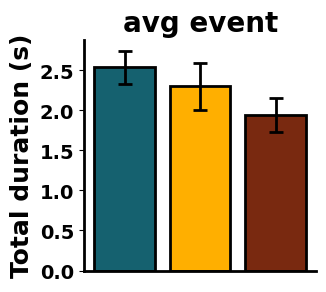

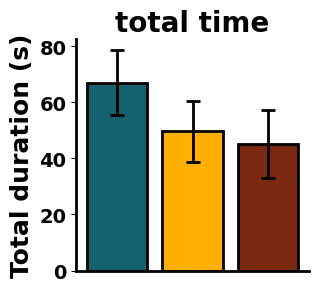

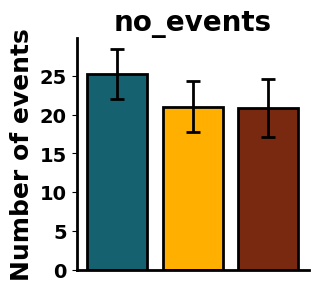

In [13]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'novel': hex_2_rgb('#15616F'),  
                'short-term familiar\n(exposure 2)': (1.0, 0.6862745098039216, 0.0),
                'long-term familiar': hex_2_rgb('#792910')
                }
hatches = ['','','']  
edges = ['black', 'black', 'black']
avg_events = []
sem_events = []
for metric in ['avg event', 'total time', 'no_events']:
    avg_events = final_result.loc[metric].values
    sem_events = final_sem.loc[metric].values
    avg_events = avg_events[np.array([2,1,0])]
    sem_events = sem_events[np.array([2,1,0])]
    plt.figure(figsize= (3,3))      
    plt.bar(color_id_dict.keys(), avg_events, yerr = sem_events,
                color = color_id_dict.values(), hatch = hatches,
                edgecolor = edges, linewidth = 2,
                capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
    plt.xticks([],rotation=45)
    if metric != 'no_events':
        plt.ylabel('Total duration (s)', fontsize = 18)
    else:
        plt.ylabel('Number of events', fontsize = 18)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
    plt.gca().spines['left'].set_linewidth(2) 
    plt.title(f'{metric}', fontsize = 20)
    plt.show()


# Order of exposure EDA

In [15]:
subject_means_order = event_overview.groupby(['level_1', 'subject'])[['exposure_1', 'exposure_2', 'exposure_3']].mean()

# Step 2: Average across subjects for each level_1 category  
final_result_order = subject_means_order.groupby('level_1')[['exposure_1', 'exposure_2', 'exposure_3']].mean()
final_sem_order = subject_means_order.groupby('level_1')[['exposure_1', 'exposure_2', 'exposure_3']].sem()

final_result_order
final_sem_order

,exposure_1,exposure_2,exposure_3
level_1,,,
avg event,0.225905,0.276477,0.201966
no_events,2.624881,2.637339,3.418455
total time,9.125847,8.716277,11.517471


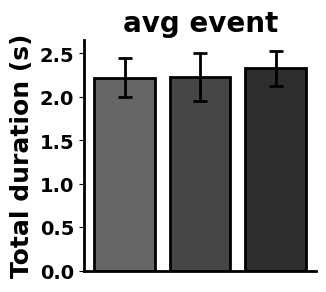

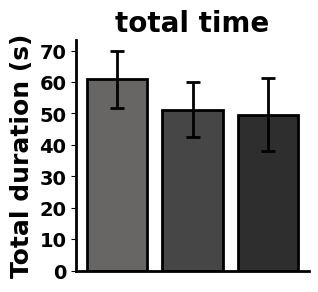

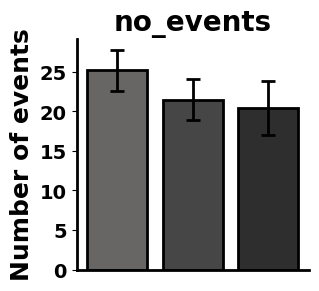

In [16]:
plt.rcParams['font.weight'] = 'bold'  # Set font weight to bold (not bold)
plt.rcParams['axes.titleweight'] = 'bold'  # Set axis title font weight to bold
plt.rcParams['axes.labelweight'] = 'bold'  # Set axis label font weight to bold

color_id_dict = {'exposure 1': "#686565",  
                'exposure 2': "#464646",
                'exposure 3': "#2E2E2E"
                }
hatches = ['','','']  
edges = ['black', 'black', 'black']
avg_events = []
sem_events = []
for metric in ['avg event', 'total time', 'no_events']:
    avg_events = final_result_order.loc[metric].values
    sem_events = final_sem_order.loc[metric].values
    plt.figure(figsize= (3,3))      
    plt.bar(color_id_dict.keys(), avg_events, yerr = sem_events,
                color = color_id_dict.values(), hatch = hatches,
                edgecolor = edges, linewidth = 2,
                capsize = 5, error_kw={'elinewidth': 2, 'capthick': 2})
    plt.xticks([],rotation=45)
    if metric != 'no_events':
        plt.ylabel('Total duration (s)', fontsize = 18)
    else:
        plt.ylabel('Number of events', fontsize = 18)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
    plt.gca().spines['left'].set_linewidth(2) 
    plt.title(f'{metric}', fontsize = 20)
    plt.show()


# GLM STATS

In [ ]:
event_overview

,level_0,level_1,baseline,cagemate,exposure 1,exposure 2,exposure 3,familiar,novel,order,subject
0,11_CNF_merged.rec1.1,no_events,15.0,48.000000,48.000000,38.000000,39.000000,39.000000,38.000000,CNF,11
1,11_CNF_merged.rec1.1,avg event,2.5,2.065847,2.065847,3.468418,3.995510,3.995510,3.468418,CNF,11
2,11_CNF_merged.rec1.1,total time,37.5,99.160650,99.160650,131.799900,155.824900,155.824900,131.799900,CNF,11
3,11_NCF_merged.rec1.1,no_events,15.0,13.000000,25.000000,13.000000,32.000000,32.000000,25.000000,NCF,11
4,11_NCF_merged.rec1.1,avg event,2.5,1.211127,1.719094,1.211127,1.474645,1.474645,1.719094,NCF,11
5,11_NCF_merged.rec1.1,total time,37.5,15.744650,42.977350,15.744650,47.188650,47.188650,42.977350,NCF,11
6,12_CNF_merged.rec1.2,no_events,15.0,41.000000,41.000000,23.000000,20.000000,20.000000,23.000000,CNF,12
7,12_CNF_merged.rec1.2,avg event,2.5,2.115424,2.115424,2.115872,1.593757,1.593757,2.115872,CNF,12
8,12_CNF_merged.rec1.2,total time,37.5,86.732400,86.732400,48.665050,31.875150,31.875150,48.665050,CNF,12
9,13_NCF_merged.rec1.3,no_events,15.0,18.000000,29.000000,18.000000,9.000000,9.000000,29.000000,NCF,13


In [ ]:
def get_exposure_number(condition, order):
    # Create mapping from condition to letter
    condition_to_letter = {
        'familiar': 'F',
        'cagemate': 'C', 
        'novel': 'N'
    }
    
    # Find the position of the condition's letter in the order string
    letter = condition_to_letter[condition]
    position = order.index(letter) + 1  # +1 because we want 1-based indexing
    
    return position

df_long = event_overview.melt(id_vars=['level_0', 'subject', 'level_1', 'order'], 
                       value_vars=['cagemate', 'familiar', 'novel'],
                       var_name='condition', 
                       value_name='score')
df_long

df_long['exposure_number'] = df_long.apply(lambda row: get_exposure_number(row['condition'], row['order']), axis=1)
df_long
df_long.to_csv('pilot2/only_subjects/only_subjects_behavior_data.csv', index=False)

In [ ]:
total_time = event_overview[['level_1'] == 'total time']  
total_time

,level_0,level_1,baseline,cagemate,exposure 1,exposure 2,exposure 3,familiar,novel,order,subject
2,11_CNF_merged.rec1.1,total time,37.5,99.16065,99.16065,131.79990,155.82490,155.82490,131.79990,CNF,11
5,11_NCF_merged.rec1.1,total time,37.5,15.74465,42.97735,15.74465,47.18865,47.18865,42.97735,NCF,11
8,12_CNF_merged.rec1.2,total time,37.5,86.73240,86.73240,48.66505,31.87515,31.87515,48.66505,CNF,12
11,13_NCF_merged.rec1.3,total time,37.5,23.49045,56.60035,23.49045,28.25815,28.25815,56.60035,NCF,13
14,21_FCN_merged.rec2.1,total time,37.5,44.07495,28.96465,44.07495,36.93340,28.96465,36.93340,FCN,21
17,21_NCF_merged.rec2.1,total time,37.5,34.09250,62.00950,34.09250,7.56365,7.56365,62.00950,NCF,21
20,22_FCN_merged.rec2.2,total time,37.5,3.94970,17.98005,3.94970,16.12305,17.98005,16.12305,FCN,22
23,22_NCF_merged.rec2.2,total time,37.5,9.28535,29.90020,9.28535,27.25370,27.25370,29.90020,NCF,22
26,23_CNF_merged.rec2.3,total time,37.5,17.92370,17.92370,43.43690,114.53300,114.53300,43.43690,CNF,23
29,23_NFC_merged.rec2.3,total time,37.5,218.84255,120.11825,138.02300,218.84255,138.02300,120.11825,NFC,23
